## Indice
1. [Introduccion](#Introduccion)
2. [Scrapping](#Scrapping)
3. [Integración y consolidación de datasets climáticos](#Integracion-y-consolidacion-de-datasets-climaticos)
4. [Exploracion de la estructura de los datos](#Exploracion-de-la-estructura-de-los-datos.)
5. [Proceso de Transformación y Limpieza de Datos](#Proceso-de-Transformacion-y-Limpieza-de-Datos)
6. [Análisis estadístico descriptivo ](#analisis-estadistico-descriptivo)  
7. [Construcción de gráficas](#Construccion-de-graficas)
8. [Análisis de tendencias](#analisis-de-tendencias)
9. [Comentarios y conclusiones](#comentarios-y-conclusiones)

## Introduccion
El presente proyecto tiene como objetivo realizar un análisis exploratorio de datos detallado sobre las condiciones climatológicas registradas en la estación 25015 - Culiacán (DGE), ubicada en el estado de Sinaloa, México. El estudio abarca un periodo histórico que va desde 1961 hasta 2016, permitiendo observar comportamientos atmosféricos a largo plazo en una de las regiones agrícolas más importantes del país. Utilizando el metódo de Scrapping es que se extraen los datos para el estudio y gracias a herramientas como matplotlib y seaborn es que se hace un analisis con graficos para visualizar los datos. 

## Scrapping
Para la extraccion de datos se realizo la tecnica de scrapping la cual consiste en una tecnica automatizada para extraer informacion de una pagina web.

**Librerias y metodos utilizados**  
**Os:** Módulo estándar que permite interactuar con el sistema operativo, facilitando la automatización de tareas como la gestión de archivos, directorios y rutas.  
**Time:** módulo estándar incorporado para manejar operaciones relacionadas con el tiempo.    
**Selenium:** Biblioteca de código abierto utilizada para automatizar navegadores web.  
**ActionChains()** Esta funcion se utilza para acciones complejas como doble clic.  
**webdriver_manager:** Gestiona las configuraciones del navegador, como la ruta de descarga.  
**By.LINK_TEXT:** Busca un enlace por el texto exacto que ve el usuario.  
**By.XPATH:** Permite buscar elementos por su posición, texto parcial o jerarquía.  
**By.TAG_NAME:** Busca por etiquetas HTML  

Primeramente hicimos la configuracion inicial, estableciendo la ruta donde se guardaran los data sets y configuraciones del navegador

In [ ]:
import os
import time
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import Select, WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.by import By
from selenium.webdriver.common.action_chains import ActionChains
from webdriver_manager.chrome import ChromeDriverManager

download_path = os.path.join(os.getcwd(), "datos_conagua")
if not os.path.exists(download_path):
    os.makedirs(download_path)

# 1. Configuración inicial
chrome_options = Options()

prefs = {"download.default_directory": download_path}
chrome_options.add_experimental_option("prefs", prefs)
chrome_options.add_experimental_option("detach", True) #Dejar la ventana abierta

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=chrome_options)
actions = ActionChains(driver)
wait = WebDriverWait(driver, 15)


La pagina donde se extraeran los datos es cucapa-clicom, una pagina creada por el Centro de Investigación Científica y de Educación Superior de Ensenada (CICESE) el cual se encarga de recopilar informacion climatologica de todo México.

In [ ]:
driver.get("https://cucapa-clicom.cicese.mx/") 

**Paso 1:** El primer paso que realiza el script es dar click al boton *Descarga de Datos* ubicado en la parte superior de la pagina. 

In [ ]:
btn_pestana_descarga = wait.until(EC.element_to_be_clickable((By.LINK_TEXT, "Descarga de Datos")))
btn_pestana_descarga.click()

**Paso 2:** Despues de acceder a la pagina y entrar a la parte de descarga de datos, debemos rellenar un formulario con toda la informacion necesaria para descargar el data set, el segundo paso se encarga de dar click en el primer dropdown de la pagina y seleccionar el estado de Sinaloa.

In [ ]:
print("Intentando seleccionar el estado por índice...")
# 1. Buscamos todos los 'select' que hay en la página
dropdowns = wait.until(EC.presence_of_all_elements_located((By.TAG_NAME, "select")))
# El primer dropdown (índice 0) es la seccion de ESTADO
menu_estado = dropdowns[0] 
# 2. Asegurarnos de que sea visible y darle clic
driver.execute_script("arguments[0].scrollIntoView();", menu_estado)
time.sleep(1) # Pausa breve para el scroll
# 3. Usar la clase Select para elegir Sinaloa
select_estado = Select(menu_estado) 
# Buscamos por texto
select_estado.select_by_visible_text("Sinaloa")
print("¡Sinaloa seleccionado correctamente!")  
# Esperamos a que la página reaccione y cargue las estaciones
time.sleep(3)

**Paso 3:** En el tercer paso el script busca el input el cual es el de la estacion, despues de encontrarlo lo rellena con CULIACAN (CAADES) que es la estacion de la cual extraeremos los datos y despues da clic en el botón de buscar.

In [ ]:
print("Buscando el cuadro de búsqueda...")
# Buscamos todos los inputs y filtramos el que es de texto y está visible
todos_los_inputs = driver.find_elements(By.TAG_NAME, "input")
input_estacion = None
for i in todos_los_inputs:
    tipo = i.get_attribute("type")
    # El cuadro de búsqueda suele ser el único input tipo text visible
    if tipo == "text" and i.is_displayed():
        input_estacion = i
        break
    print("Cuadro encontrado. Ingresando 'CULIACAN (CAADES)'...")
    # Limpiamos e ingresamos
    input_estacion.clear()
    input_estacion.send_keys("CULIACAN (CAADES)")
    
    # Localizar el botón Buscar
    print("Presionando botón Buscar...")
    boton_buscar = wait.until(EC.element_to_be_clickable((By.XPATH, "//*[text()='Buscar']")))
    boton_buscar.click()
    
    # Esperamos a que la lista de resultados cargue
    time.sleep(4)

**Paso 4:** En el cuarto paso el script busca entre la lista de todas las estaciones la de Culliacán y da doble click para seleccionarla.

In [ ]:

# 1. Localizamos el elemento en la lista. 
# Usamos un XPATH que busque el texto con la estacion.
selector_resultado = "//*[contains(text(), 'CULIACAN (CAADES), SIN')]"

# Esperamos a que el elemento sea visible y esté listo
estacion_resultado = wait.until(EC.visibility_of_element_located((By.XPATH, selector_resultado)))

# 2. Scroll para asegurar que el elemento esté centrado y Selenium no falle
driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", estacion_resultado)
time.sleep(1) # Pausa para que el scroll termine

# 3. Ejecutar el doble clic
print("Realizando doble clic...")
actions.double_click(estacion_resultado).perform()

print("¡Estación movida a 'Seleccionadas' con éxito!")
time.sleep(2) # Espera para ver el cambio en pantalla

**Paso 5:** En el quinto y ultimo paso el script realiza un ciclo de descargas, en cada ciclo selecciona cada variable la cual sera cada columna de nuestro Data Frame final, estas son: Tmax, Tmin, Precipitacion y Evaporacion. Despues de seleccionar da clic en el boton de descargar. Este botón salta una ventana emergente con un link que al presionarlo nos descarga el data set de la variable seleccionada.

In [ ]:
# Verificamos los nombres.
variables_a_descargar = ["Tmax", "Tmin", "Precipitación", "Evaporación"]
print("Iniciando ciclo de descargas...")
#Ciclo para descargar los 4 datasets
for var in variables_a_descargar:
    print(f"\n--- Procesando: {var} ---")
    
    # 1. Refrescar dropdowns
    dropdowns = wait.until(EC.presence_of_all_elements_located((By.TAG_NAME, "select")))
    menu_variable = dropdowns[1] 
    Select(menu_variable).select_by_visible_text(var)
    time.sleep(3) # Aumentamos a 3 segundos para que el botón se estabilice

    # 2. LOCALIZACIÓN DINÁMICA DEL BOTÓN
    print("Buscando botón de generación por XPATH relativo...")
    # Buscamos cualquier elemento que tenga el texto 'Descargar' y sea clicable
    boton_generar = wait.until(EC.element_to_be_clickable((By.XPATH, "//*[contains(text(), 'Descargar')]")))

    # 3. EJECUTAR CLIC
    if boton_generar:
        driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", boton_generar)
        time.sleep(1)
        # Forzamos el click con JS para evitar errores de intercepción
        driver.execute_script("arguments[0].click();", boton_generar)
        print("Botón gris presionado.")
    
    # 4. Clic al enlace descargable
    print("Esperando enlace azul...")
    # El enlace azul suele estar en un contenedor con ID mensaje 
    enlace_csv = wait.until(EC.element_to_be_clickable((By.PARTIAL_LINK_TEXT, ".csv")))
    print(f"¡Enlace encontrado! Descargando {var}...")
    
    driver.execute_script("arguments[0].click();", enlace_csv)
    time.sleep(7) # Tiempo para que baje el archivo
    
    # 5. CERRAR POP-UP con ESC
    actions.send_keys(webdriver.common.keys.Keys.ESCAPE).perform()
    time.sleep(1)
        

## Integracion y consolidacion de datasets climaticos

Lo primero que hicimos fue unir los archivos individuales de la estación **25015 - Culiacán (DGE)** obtenidos mediante la técnica de scrapping, los unimos en un solo archivo para facilitar el acceso a los datos. Cada dataset contenía una variable climática diferente: precipitación, evaporación, temperatura máxima y temperatura mínima. Para poder analizarlas juntas, fue necesario construir una columna de fecha común y combinar todos los registros en un mismo DataFrame.

**Funciones y atributos utilizados:**  
**1.- import pandas as pd:** Importa la librería pandas, utilizada para leer, limpiar, unir y manipular los datasets en forma de DataFrame.  
**2.- import numpy as np:** Importa numpy, librería usada para trabajar con datos numéricos y valores especiales durante el procesamiento.  
**3.- import os:** Permite trabajar con rutas de archivos y verificar si los datasets existen dentro de la carpeta indicada.  
**4.- os.path.join():** Construye las rutas de los archivos de forma ordenada, uniendo la carpeta `Datasets` con el nombre de cada archivo. Esto evita escribir rutas manualmente varias veces.  
**5.- Diccionario de archivos:** Se utilizó un diccionario para relacionar cada variable climática (`PRECIP`, `EVAP`, `TMAX`, `TMIN`) con el archivo CSV correspondiente. Esto facilita la organización y lectura de los datos.  
**6.- Encabezado de metadatos:** Se definió un texto inicial con información de la estación, como nombre, estado, municipio, latitud, longitud y altitud. Este encabezado se agrega al archivo final para conservar el formato de una base climatológica.  
**7.- def cargar_y_limpiar():** Función creada para leer cada archivo, limpiar su estructura y regresar solamente las columnas necesarias: `FECHA` y la variable climática correspondiente.  
**8.- os.path.exists():** Verifica si el archivo existe antes de intentar leerlo. Si no se encuentra, se devuelve un DataFrame vacío con las columnas esperadas para evitar errores en la ejecución.  
**9.- pd.read_csv():** Lee cada archivo CSV. Se utiliza `skiprows=7` porque las primeras líneas contienen información descriptiva y no forman parte de la tabla de datos.  
**10.- astype(str):** Convierte los valores de día, mes y año a texto para poder unirlos y construir la columna `FECHA`.  
**11.- str.zfill(2):** Rellena con cero a la izquierda los días y meses de un solo dígito. Por ejemplo, convierte `1` en `01`. Esto permite mantener un formato de fecha uniforme.  
**12.- rename():** Cambia el nombre de la columna `Datos` por el nombre real de la variable que contiene el archivo, como `PRECIP`, `EVAP`, `TMAX` o `TMIN`.  
**13.- merge():** Une los DataFrames usando la columna `FECHA` como llave. Se aplica varias veces para integrar precipitación, evaporación, temperatura máxima y temperatura mínima en una sola tabla.  
**14.- how='outer':** Indica que la unión debe conservar todas las fechas disponibles, aunque alguna variable no tenga registro en ciertas fechas. Esto ayuda a no perder información y permite identificar valores faltantes.  
**15.- pd.to_datetime():** Convierte temporalmente la columna `FECHA` a tipo fecha usando el formato `%d/%m/%Y`, para poder ordenar los registros cronológicamente.  
**16.- sort_values():** Ordena el DataFrame final de acuerdo con la fecha, dejando los registros en secuencia temporal.  
**17.- drop():** Elimina la columna auxiliar `temp_date`, que solo se utilizó para ordenar los datos.  
**18.- fillna('Nulo'):** Reemplaza los valores faltantes por la palabra `Nulo`, manteniendo un formato claro para identificar datos no disponibles en el archivo consolidado.  
**19.- open():** Abre o crea el archivo de salida donde se guardará el dataset unificado. Se usa con codificación `utf-8` para conservar acentos y caracteres especiales.  
**20.- iterrows():** Recorre fila por fila el DataFrame final para escribir cada registro en el archivo consolidado con el formato deseado.  
**21.- f.write():** Escribe primero el encabezado de metadatos y después cada fila del DataFrame en el archivo final `25015_CULIACAN_DGE_1961_a_2016.csv`.  

Al finalizar este proceso se obtiene un solo archivo con las columnas **FECHA**, **PRECIP**, **EVAP**, **TMAX** y **TMIN**, listo para las siguientes etapas de exploración, limpieza, análisis estadístico y visualización.



In [2]:
import pandas as pd
import numpy as np
import os

# Configuración de carpetas y archivos
carpeta_datos = 'Datasets'
archivos = {
    'PRECIP': os.path.join(carpeta_datos, '25015-CULIACAN (DGE)-SIN-Precip.csv'),
    'EVAP':   os.path.join(carpeta_datos, '25015-CULIACAN (DGE)-SIN-Evap.csv'),
    'TMAX':   os.path.join(carpeta_datos, '25015-CULIACAN (DGE)-SIN-Tmax.csv'),
    'TMIN':   os.path.join(carpeta_datos, '25015-CULIACAN (DGE)-SIN-Tmin.csv')
}

# Texto del encabezado exactamente igual al formato de BAdiraguato
encabezado_texto = """CNA-SMN-CG-GMC-SMAA-CLIMATOLOGIA
BASE DE DATOS CLIMATOLOGICA
 
ESTACION  : 25015
NOMBRE    : CULIACAN (DGE)
ESTADO    : SINALOA
MUNICIPIO : CULIACAN
SITUACIÓN : OPERANDO
ORGANISMO : CONAGUA-DGE
CVE-OMM   : Nulo
LATITUD   : 024.792°
LONGITUD  : -107.390°
ALTITUD   : 39 m
 
           PRECIP  EVAP   TMAX   TMIN
  FECHA     (MM)   (MM)   (°C)   (°C)
"""

def cargar_y_limpiar(ruta_archivo, nombre_variable):
    if not os.path.exists(ruta_archivo):
        print(f"No se encontró: {ruta_archivo}")
        return pd.DataFrame(columns=['FECHA', nombre_variable])
    
    df = pd.read_csv(ruta_archivo, skiprows=7)
    df['FECHA'] = (df['Día'].astype(str).str.zfill(2) + '/' + 
                   df['Mes'].astype(str).str.zfill(2) + '/' + 
                   df['Anio'].astype(str))
    df = df.rename(columns={'Datos': nombre_variable})
    return df[['FECHA', nombre_variable]]

# Cargamos y unimos
df_precip = cargar_y_limpiar(archivos['PRECIP'], 'PRECIP')
df_evap = cargar_y_limpiar(archivos['EVAP'], 'EVAP')
df_tmax = cargar_y_limpiar(archivos['TMAX'], 'TMAX')
df_tmin = cargar_y_limpiar(archivos['TMIN'], 'TMIN')

df_final = df_precip.merge(df_evap, on='FECHA', how='outer')
df_final = df_final.merge(df_tmax, on='FECHA', how='outer')
df_final = df_final.merge(df_tmin, on='FECHA', how='outer')

# Ordenar por fecha cronológicamente
df_final['temp_date'] = pd.to_datetime(df_final['FECHA'], format='%d/%m/%Y', errors='coerce')
df_final = df_final.sort_values('temp_date').drop(columns=['temp_date'])

# Reemplazar vacíos por "Nulo"
df_final = df_final.fillna('Nulo')

# Guardar como archivo de texto (.txt) con encabezado
nombre_salida = './Datasets/25015_CULIACAN_DGE_1961_a_2016.csv'

with open(nombre_salida, 'w', encoding='utf-8') as f:
    f.write(encabezado_texto)
    # Escribimos los datos línea por línea con espaciado similar al original
    for _, row in df_final.iterrows():
        linea = f"{row['FECHA']}  {str(row['PRECIP']).ljust(6)}  {str(row['EVAP']).ljust(6)}  {str(row['TMAX']).ljust(6)}  {str(row['TMIN']).ljust(6)}\n"
        f.write(linea)

print(f"x   Proceso completado. Archivo generado: {nombre_salida}")

x   Proceso completado. Archivo generado: ./Datasets/25015_CULIACAN_DGE_1961_a_2016.csv


# Exploracion de la estructura de los datos.
Lo primero que hicimos fue analizar y explorar los datos y la estructura del archivo mediante diferentes funciones de la libreria pandas.  

**Funciones y atributos utilizados:**  
**1.-read_csv:** Lectura del archivo mediante pandas.  
**2.- Skiprows:** Realiza saltos de linea del archivo. Lo utilizamos ya que las primeras lineas del txt tienen informacion adicional al Data Frame. Los registros comienzan en la linea 20.  
**3.- Skipfooter:** Al contrario de skiprows, skipfooter hace los saltos empezando de la ultima linea del archivo. Lo utilizamos ya que el ultimo registro tiene guiones en vez de datos.  
**4.- Names:** Mediante una lista asigna los nombres de las columnas.  
**5.- Sep:** Se utiliza para definir un delimitador entre columnas. Lo utilizamos ya que pandas tomaba las columnas de names como columnas independientes y les asignaba nulos a todos los registros. r (raw) indica que debe tomar todos los caracteres como datos, \s+ es para los espacios en blanco.  
**6.-na_values** Sirve para indicar que una cadena es de tipo NaN. Le indicamos que los registros con el dato 'Nulo' contaran como nules. Esto solo para el analisis del archivo por lo que no modifica el dataframe.  
**7.- info():** Muestra un resumen del dataframe. Datos como el numero de registros, nombres de columna, tipos de dato, cantidad de nulos etc.  
**8.- shape:** Devuelve una tupla con las dimensiones del data frame (numero de filas y columnas).  
**9.- head():** Regresa las primeras filas del data frame.  
**10.- tail():** Muestra las ultimas filas del data frame.  
**11.- isnull().sum():** Hace la suma de todos los nulos por cada columna tambien muestra tipo de dato.  
**12.- nunique():** Devuelve la cantidad de registors unicos por cada columna.  

Lectura de archivos mediante pandas:

In [3]:
#Importacion de pandas y lectura del archivo.
import pandas as pd
df=pd.read_csv('Datasets/25015_CULIACAN_DGE_1961_a_2016.csv',
skiprows=16, #saltamos las primeras 18 lineas del archivo
names=['FECHA','PRECIP','EVAP','TMAX','TMIN'] , #Nombres de las columnas 
sep=r'\s+',#Separamos las columnas correctamente 
na_values='Nulo', #Asignamos como nulos los datos que contengan 'Nulo'
) 
df

,FECHA,PRECIP,EVAP,TMAX,TMIN
0,01/01/1961,0.0,2.90,22.0,10.5
1,02/01/1961,0.0,2.70,25.0,9.0
2,03/01/1961,0.0,3.70,29.0,10.0
3,04/01/1961,0.0,2.50,22.0,13.0
4,05/01/1961,0.0,1.10,24.0,14.0
...,...,...,...,...,...
20235,27/05/2016,0.0,4.89,39.5,21.5
20236,28/05/2016,0.0,9.27,39.5,19.5
20237,29/05/2016,0.0,8.77,39.5,20.0
20238,30/05/2016,2.3,6.75,35.0,22.5


El Data Frame tiene un total 19574 registros, 5 columnas (FECHA, PRECIP, EVAP, TMAX Y TMIN todas de tipo String). 

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20240 entries, 0 to 20239
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   FECHA   20240 non-null  str    
 1   PRECIP  20173 non-null  float64
 2   EVAP    19867 non-null  float64
 3   TMAX    20127 non-null  float64
 4   TMIN    20116 non-null  float64
dtypes: float64(4), str(1)
memory usage: 790.8 KB


In [5]:
df.shape

(20240, 5)

**Cada columna esta compuesta por:**  
**1.-Fecha:** fecha en dia, mes y año de la muestra.  
**2.-Precip:** precipitacion en milimietros de la muestra.  
**3.-Evap:** evaporacion en milimietros de la muestra.  
**4.-TMAX:** temperatura maxima en grados celsius de la muestra.  
**5.-TMIN** temperatura minima en grados celcius de la muestra.  


Las primeras 10 columnas muestran una precipitacion de 0, evaporacion en nulos, TMAX y TMIN muestran la temperatura maxima y minima en la fecha correspondiente.

In [6]:
df.head(10)

,FECHA,PRECIP,EVAP,TMAX,TMIN
0,01/01/1961,0.0,2.9,22.0,10.5
1,02/01/1961,0.0,2.7,25.0,9.0
2,03/01/1961,0.0,3.7,29.0,10.0
3,04/01/1961,0.0,2.5,22.0,13.0
4,05/01/1961,0.0,1.1,24.0,14.0
5,06/01/1961,0.0,1.9,22.0,13.0
6,07/01/1961,0.0,4.0,24.0,8.0
7,08/01/1961,0.0,6.3,30.0,9.0
8,09/01/1961,0.0,5.2,31.0,14.0
9,10/01/1961,0.0,3.6,30.0,10.0


A diferencia de los primeros 10 registros, los ultimos 10 si cuentan con una precipitacion y evaporacion ademas de la temperatura maxima y minima.

In [7]:
df.tail(10)

,FECHA,PRECIP,EVAP,TMAX,TMIN
20230,22/05/2016,0.0,8.91,37.5,21.0
20231,23/05/2016,0.0,7.19,38.0,19.0
20232,24/05/2016,0.0,6.99,36.0,21.0
20233,25/05/2016,0.0,6.27,33.0,25.0
20234,26/05/2016,0.0,1.85,37.5,24.5
20235,27/05/2016,0.0,4.89,39.5,21.5
20236,28/05/2016,0.0,9.27,39.5,19.5
20237,29/05/2016,0.0,8.77,39.5,20.0
20238,30/05/2016,2.3,6.75,35.0,22.5
20239,31/05/2016,0.0,1.18,34.5,24.0


In [8]:
df.isnull().sum()

FECHA       0
PRECIP     67
EVAP      373
TMAX      113
TMIN      124
dtype: int64

El data frame cuenta con 19574 registros. **Fecha tiene todos sus registros unicos** esto significa que no existen fechas repetidas.

In [9]:
df.nunique()

FECHA     20240
PRECIP      476
EVAP       1131
TMAX         68
TMIN         57
dtype: int64

### Contabilizar numero de datos faltantes por fecha.  
Funciones y atributos utilizados:  
**1.-to_datetime():** Esta funcion convierte el tipo de dato a datetime.  
**2.-dayfirst:** Este atributo indica que el formato de la fecha es dia/mes/año. Lo utilizamos por que ese es el formato que tiene el archivo.  
**3.-dt.date:** Toma solamente la fecha del datetime dejando fuera la hora. Lo utilizamos por que no necesitamos la hora para contabilizar los dias faltantes.  
**4.-.loc:** Toma un registro determinado mediante fila-columna.  
**5.-date_range():** Crea un rango de fechas.   
**6.-difference():** Compara elementos entre dos series y guarda los elementos diferentes en otra serie.  


Lo primero que hicimos fue cambiar el tipo de dato de la columna fecha a date. Como date_time nos da el formato dia-mes-año hora:minuto:segundo utilizamos dt.date para solo obtener la fecha sin la hora.  
Despues inicializamos el rango de fechas que tiene el dataframe con date range y las fechas de inicio y final y una frecuendia en dias.  
A continuacion comparamos el rango completo con las fechas existentes en el dataframe y lo guardamos en fechas faltantes para despues imprimirlo.



In [10]:
def dias_faltantes(df):
    
    df['FECHA'] = pd.to_datetime(df['FECHA'],dayfirst=True)#Conversion de columna FECHA a datetime
    df['FECHA'] = df['FECHA'].dt.date #Tomamos solamente la fecha
    #Tomamos el rango de fechas del dataframe 1961-01-01 a 2018-07-31
    inicio=df.loc[0,'FECHA'] 
    final=df.loc[df.index[-1],'FECHA'] #.index[-1] para tomar el ultimo elemento de la columna
    rango_completo = pd.date_range(start=inicio, end=final, freq='D')
    fechas_faltantes = rango_completo.difference(df['FECHA'])
    print(f"Dias faltantes entre {inicio} y {final}: {len(fechas_faltantes)}")

#Ejecucion del metodo
dias_faltantes(df)

Dias faltantes entre 1961-01-01 y 2016-05-31: 0


### ¿Cuántos datos nos faltan por cada año?
Antes de rellenar los espacios nulos, es muy importante saber en qué años la estación de Acatitán dejó de reportar datos. Esto nos ayuda a ver si la falta de información es algo de un solo año o si es constante.

In [11]:
def contar_nulos_por_anio(df_temp):
    """
    Función para contar cuántos datos faltan en cada columna, 
    separados por cada año del registro.
    """
    # Convertimos la columna de fecha a formato datetime, indicando que el día se muestra antes que el mes con el parámetro (dayfirst=True)
    df_temp['FECHA'] = pd.to_datetime(df_temp['FECHA'], dayfirst=True)

    # Creamos la columna 'Año' extrayendo el año de la columna 'FECHA'
    df_temp['Año'] = df_temp['FECHA'].dt.year

    # Definimos las columnas numéricas que queremos analizar
    cols_clima = ['PRECIP', 'EVAP', 'TMAX', 'TMIN']

    # Calculamos los nulos por año
    # isnull() crea True/False, al agrupar por 'Año' y usar .sum(), contamos cuántos True (nulos) hay por cada año
    nulos_por_anio = df[cols_clima].isnull().groupby(df['Año']).sum()

    # Mostramos el resultado de manera clara 
    print("--- Cantidad de datos nulos detectados por Año ---")
    display(nulos_por_anio)

    # Opcional: Ver el total general de nulos antes de proceder
    print("\nTotal de nulos en todo el registro:")
    print(df[cols_clima].isnull().sum())

    return df_temp

# Se manda a llamar la función
df = contar_nulos_por_anio(df)

--- Cantidad de datos nulos detectados por Año ---


,PRECIP,EVAP,TMAX,TMIN
Año,,,,
1961,0,0,0,0
1962,0,1,0,0
1963,0,12,9,8
1964,0,27,10,11
1965,0,1,0,0
1966,0,0,0,0
1967,2,0,0,0
1968,0,1,0,0
1969,2,0,18,29



Total de nulos en todo el registro:
PRECIP     67
EVAP      373
TMAX      113
TMIN      124
dtype: int64


## Proceso de Transformacion y Limpieza de Datos
En esta etapa, convertimos los datos crudos en un formato apto para el análisis estadístico. El proceso se ha dividido en funciones específicas que permiten un manejo controlado de la información.

### Librerías y Métodos Utilizados:
* **Pandas:** Utilizada para la estructuración y limpieza del DataFrame.
* **to_datetime (errors='coerce'):** Transforma la columna de fechas. El uso de `coerce` es fundamental para la **limpieza**, ya que convierte automáticamente cualquier texto inválido (como títulos o guiones) en valores `NaT` (Not a Time), evitando errores de ejecución.
* **dropna():** Elimina las filas que no contienen fechas válidas, asegurando que solo trabajemos con registros cronológicos reales.
* **to_numeric:** Convierte las columnas de medición (Precipitación, Evaporación, etc.) de texto a números decimales para permitir el cálculo de métricas.

In [12]:
def transformar_datos(df_temp):
    """
    Función modular para convertir tipos de datos y eliminar basura de texto.
    """
    # Convertimos la columna de fecha a formato datetime, indicando que el día se muestra antes que el mes con el parámetro (dayfirst=True)
    df_temp['FECHA'] = pd.to_datetime(df_temp['FECHA'], dayfirst=True)

    # Convertimos las columnas de datos a números 
    cols_num = ['PRECIP', 'EVAP', 'TMAX', 'TMIN']
    df_temp[cols_num] = df_temp[cols_num].apply(pd.to_numeric) # Convertimos a datos númericos usando apply() para aplicar la función a cada columna
    
    return df_temp

# Llamada a la función
df = transformar_datos(df)
df.head()

,FECHA,PRECIP,EVAP,TMAX,TMIN,Año
0,1961-01-01,0.0,2.9,22.0,10.5,1961
1,1961-01-02,0.0,2.7,25.0,9.0,1961
2,1961-01-03,0.0,3.7,29.0,10.0,1961
3,1961-01-04,0.0,2.5,22.0,13.0,1961
4,1961-01-05,0.0,1.1,24.0,14.0,1961


### Tratamiento de Valores Faltantes (Nulos)
Para garantizar la integridad del Análisis Exploratorio de Datos (EDA), es necesario tratar los valores nulos identificados previamente. Rellenamos los datos faltantes con la media

In [13]:
def aplicar_limpieza_nulos(df_temp):
    """
    Rellena los espacios vacíos con el promedio de la columna.
    """
    cols_num = ['PRECIP', 'EVAP', 'TMAX', 'TMIN']
    
    # Rellenamos nulos con la media de cada columna 
    df_temp[cols_num] = df_temp[cols_num].fillna(df_temp[cols_num].mean())
    
    return df_temp

# Aplicamos la limpieza
df = aplicar_limpieza_nulos(df)
# Verificamos que ya no existan nulos
df.isnull().sum()

FECHA     0
PRECIP    0
EVAP      0
TMAX      0
TMIN      0
Año       0
dtype: int64

# Analisis estadistico descriptivo 
En esta sección generamos las métricas estadísticas que se solicitan.

**Funciones Utilizadas:**
* **describe():** Para obtener un panorama estadístico global.
* **mean(), median(), max(), min():** Para cumplir con la identificación específica de métricas requeridas en el proyecto.


In [14]:
df.describe()

,FECHA,PRECIP,EVAP,TMAX,TMIN,Año
count,20240,20240.000000,20240.000000,20240.000000,20240.000000,20240.000000
mean,1988-09-15 12:00:00,1.843900,5.816629,32.584056,17.704931,1988.210277
min,1961-01-01 00:00:00,0.000000,0.010000,14.000000,2.000000,1961.000000
25%,1974-11-08 18:00:00,0.000000,4.050000,30.000000,13.000000,1974.000000
50%,1988-09-15 12:00:00,0.000000,5.650000,33.000000,17.500000,1988.000000
75%,2002-07-24 06:00:00,0.000000,7.550000,35.500000,23.000000,2002.000000
max,2016-05-31 00:00:00,258.000000,17.900000,46.000000,29.500000,2016.000000
std,NaN,8.256141,2.390608,4.034778,5.725352,15.998303


In [15]:
def ejecutar_eda(df_temp):   

# Seleccionamos solo las columnas numéricas
    df_numeric = df[['PRECIP', 'EVAP', 'TMAX', 'TMIN']]

    # Calculamos cada métrica por separado
    media = df_numeric.mean()
    mediana = df_numeric.median()
    moda = df_numeric.mode().iloc[0]
    minimo = df_numeric.min()
    maximo = df_numeric.max()
    rango = maximo - minimo
    varianza = df_numeric.var()
    desviacion = df_numeric.std()

    # Creamos un DataFrame para el "display" final
    resumen = pd.DataFrame({
        'Media': media,
        'Mediana': mediana,
        'Moda': moda,
        'Mínimo': minimo,
        'Máximo': maximo,
        'Rango': rango,
        'Varianza': varianza,
        'Desv. Estándar': desviacion
    })

    # Mostramos el resultado
    display(resumen)

# Ejecutamos el análisis final
ejecutar_eda(df)

,Media,Mediana,Moda,Mínimo,Máximo,Rango,Varianza,Desv. Estándar
PRECIP,1.843900,0.00,0.000000,0.00,258.0,258.00,68.163862,8.256141
EVAP,5.816629,5.65,5.816629,0.01,17.9,17.89,5.715007,2.390608
TMAX,32.584056,33.00,34.000000,14.00,46.0,32.00,16.279436,4.034778
TMIN,17.704931,17.50,24.000000,2.00,29.5,27.50,32.779658,5.725352


### Interpretacion
La desviacion estandar nos indica que tan alejados estan los datos respecto a la media.   

**Precipitacion:** Esta columna es la mas alta en cuanto desviación estándar, esto indica que la mayoria de dias no llueve pero cuando llueve los valores son muy altos.  
**Evaporacion:** La evaporacion en Culiacán tiene una desviación estándar medianamente baja lo que puede indicar que la mayoria de dias existe una evaporacion constante.  
**Temperatura Maxima y Minima:** Estas dos columnas tienen una desviación estandar moderada, indicando que puede haber dias donde haya mucho calor por las tardes y mucho frios por las noches en ciertas temporadas.  

En cuanto a la media y mediana existe sesgo positivo precipitacion, evaporacion y temperatura minima. Destacando que la precipitacion tiene un sesgo considerable y la temperatura minima un sesgo pequeño indicando que podria no haber un sesgo completo. Por otra parte temperatura maxima tiene un sesgo negativo no tan alto.  

Existen valores atipicos en todos las columnas pero el mas destacable es en precipitacion, el cual tiene un dia con 258 lo que puede alterar considerablemente la media ya que como se comento anterirormente, la mayoria de dias no llueve y con este outliers podria parecer que llueve moderadamente.  

## Construccion de graficas

### Librerías y Métodos Utilizados:
* **matplotlib:** Utilizada para la visualizacion de datos en gráficas
* **subplots:** Para la separacion de graficas.
* **seaborn:** Libreria para visualizacion de datos.

### Histograma

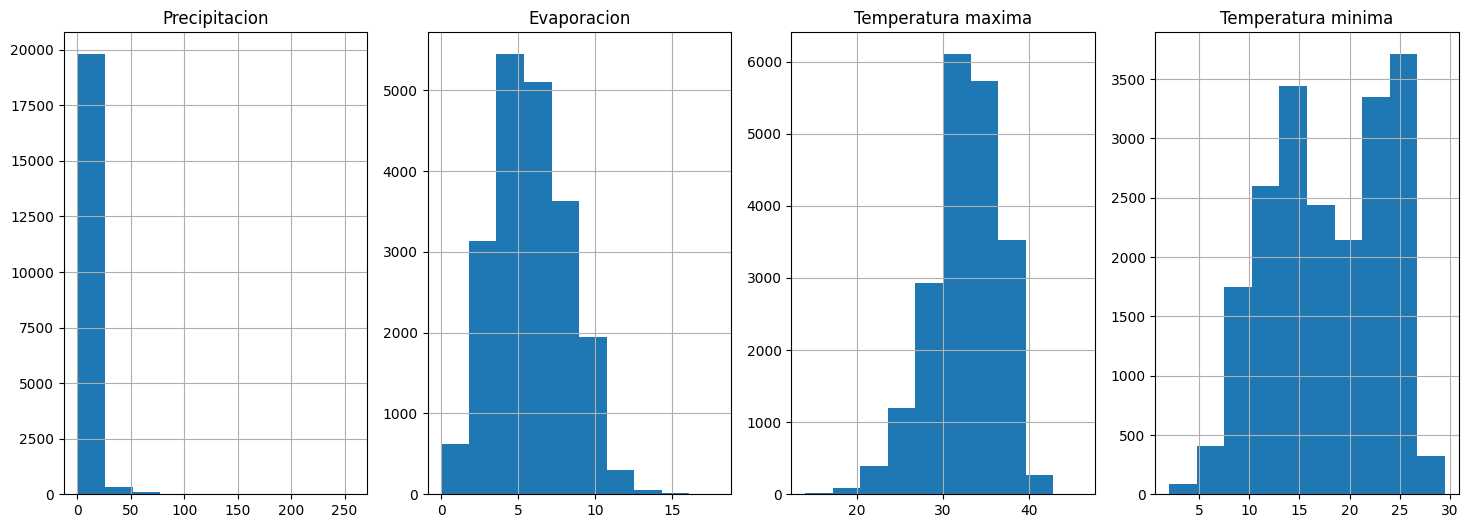

In [16]:
import matplotlib.pyplot as plt
def histograma(df_temp):
    fig, axes = plt.subplots(1, 4, figsize=(18, 6))

    df_temp['PRECIP'].hist(ax=axes[0])
    axes[0].set_title("Precipitacion")

    df_temp['EVAP'].hist(ax=axes[1])
    axes[1].set_title("Evaporacion")

    df_temp['TMAX'].hist(ax=axes[2])
    axes[2].set_title("Temperatura maxima")

    df_temp['TMIN'].hist(ax=axes[3])
    axes[3].set_title("Temperatura minima")
    plt.show()

histograma(df)
    

**Precipitacion:** El histograma muestra una distribucion completamente sesgada positivamente a la derecha. Esto confirma por qué la moda y la mediana son 0.0, mientras que la media se desplaza hasta 1.84 debido a los valores atípicos.  
**Evaporacion:** Presenta una forma de campana, aunque ligeramente inclinada hacia la izquierda. Con una distribucion sesgada positiva a la derecha levemente. La cercanía entre la media y la mediana en los datos refleja esta forma equilibrada en el histograma, indicando que la evaporación es un fenómeno constante con poca variabilidad extrema.  
**Temperatura maxima:** Este histograma presenta un sesgo negativo hacia la izquierda minimo. Esto explica por qué la mediana es mayor que la media ya que hay una gran cantidad de días muy calurosos que empujan la acumulación de datos hacia la derecha del gráfico.  
**Temperatura minima:** La temperatura minima muestra dos picos por lo tanto es una distribucion bimodal. Estos dos picos pueden estar relacionadas a las dos estaciones principales invierno y verano.

### Diagrama de densidad 

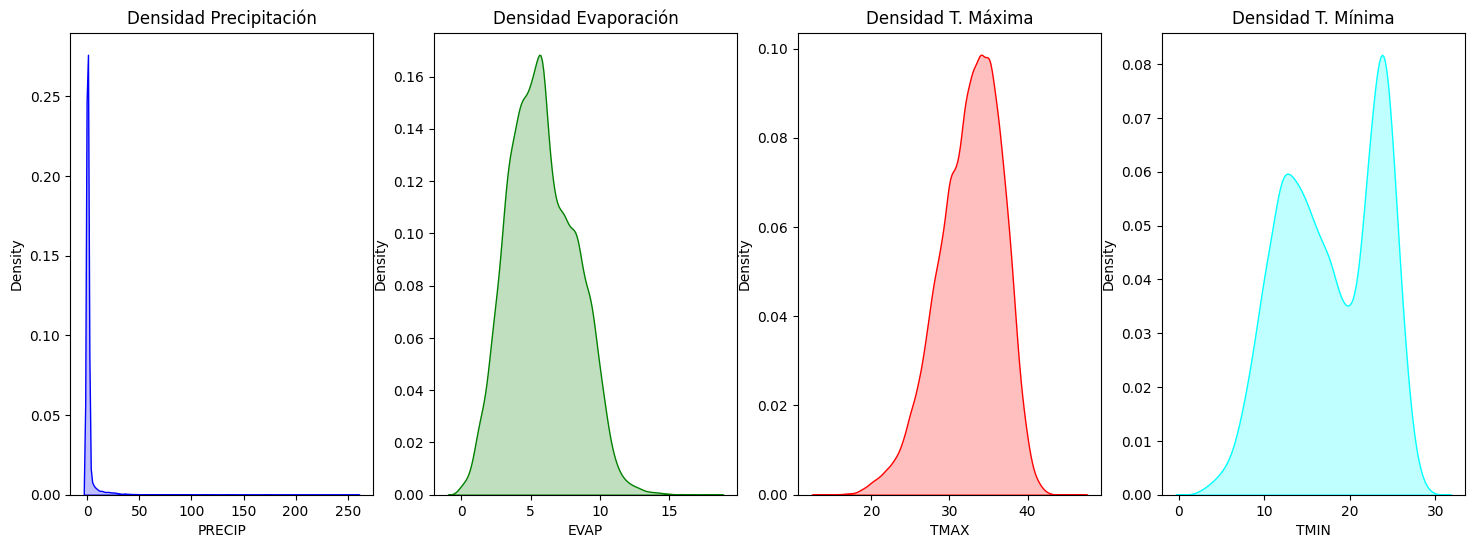

In [17]:
import seaborn as sns
def diagrama_densidad(df_temp):
    cols = ['PRECIP', 'EVAP', 'TMAX', 'TMIN']
    #Pasar las columnas a numerico para poder crear el diagrama
    df_final[cols] = df_final[cols].apply(pd.to_numeric, errors='coerce')

    fig, axes = plt.subplots(1, 4, figsize=(18, 6))

    sns.kdeplot(df_temp['PRECIP'], fill=True, ax=axes[0], color="blue")
    axes[0].set_title("Densidad Precipitación")

    sns.kdeplot(df_temp['EVAP'], fill=True, ax=axes[1], color="green")
    axes[1].set_title("Densidad Evaporación")

    sns.kdeplot(df_temp['TMAX'], fill=True, ax=axes[2], color="red")
    axes[2].set_title("Densidad T. Máxima")

    sns.kdeplot(df_temp['TMIN'], fill=True, ax=axes[3], color="cyan")
    axes[3].set_title("Densidad T. Mínima")
    
    plt.show()

diagrama_densidad(df)


**Precipitacion:** Presenta una concentración masiva en el valor , con una curva que cae abruptamente. Esto indica que los eventos de lluvia son la excepción y no la regla. Tiene la dispersión más irregular aunque su desviación estándar es 8.25, la forma del gráfico muestra que esta dispersión es causada únicamente por valores atípicos.  
**Evaporacion:** Muestra una concentración de valores muy clara entre 4 y 8 mm. La curva es suave y redondeada, lo que sugiere un fenómeno físico más predecible y menos errático que la lluvia.    
**Temperatura maxima:** Los valores se concentran fuertemente entre los 30 °C y 38 °C. La pendiente es más suave hacia la izquierda  y más pronunciada hacia la derecha.  
**Temperatura minima:** Es el gráfico más complejo con dos picos de concentración claramente definidos (aproximadamente en 13 °C y 24 °C).Estos dos picos confirman que la variabilidad de 5.72 no es ruido, sino el reflejo de dos comportamientos climáticos distintos.  
  
La evaporación y la temperatura máxima tienen las curvas más cerradas o "picudas", lo que visualmente confirma una menor dispersión relativa respecto a sus promedios.  
  
A diferencia del histograma que se ve escalonado, el diagrama de densidad elimina el ruido visual de las barras, permitiendo identificar mejor el punto exacto de la moda.  


### Boxplot 

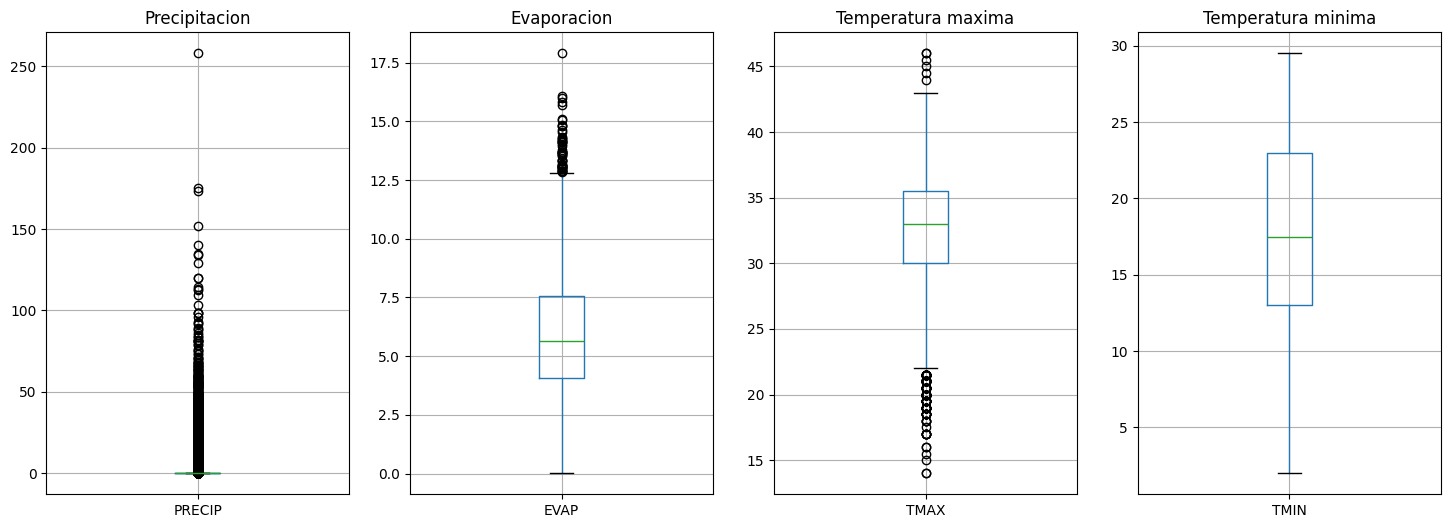

In [19]:
def boxplot(df_temp):
    fig, axes = plt.subplots(1, 4, figsize=(18, 6))

    df_temp[['PRECIP']].boxplot(ax=axes[0])
    axes[0].set_title("Precipitacion")

    df_temp[['EVAP']].boxplot(ax=axes[1])
    axes[1].set_title("Evaporacion")

    df_temp[['TMAX']].boxplot(ax=axes[2])
    axes[2].set_title("Temperatura maxima")

    df_temp[['TMIN']].boxplot(ax=axes[3])
    axes[3].set_title("Temperatura minima")
    plt.show()

boxplot(df)

**Precipitación:** La mediana es **0.00 mm**, con **Q1 = 0.00 mm** y **Q3 = 0.00 mm**, por lo que el **IQR = 0.00 mm**. Esto indica que la mayoria de los días no registran lluvia. Con la regla de 1.5 * IQR, cualquier valor mayor a 0 se considera atípico, con registros desde **0.10 mm** hasta **258.00 mm**. La dispersión está dominada por eventos extremos de lluvia y el sesgo es **positivo muy fuerte**.

**Evaporación:** La mediana es **5.65 mm**, con **Q1 = 4.05 mm** y **Q3 = 7.55 mm**, por lo que el **IQR = 3.50 mm**. Los límites para detectar atípicos son **-1.20 mm** y **12.80 mm**. Los valores atípicos detectados se encuentran por encima del límite superior, entre **12.84 mm** y **17.90 mm**. La dispersión es moderada y el sesgo es **positivo leve**, ya que algunos valores altos elevan ligeramente la media.

**Temperatura máxima:** La mediana es **33.00 °C**, con **Q1 = 30.00 °C** y **Q3 = 35.50 °C**, por lo que el **IQR = 5.50 °C**. Los límites de atípicos son **21.75 °C** y **43.75 °C**, con temperaturas desde **14.00 °C** hasta **46.00 °C**. La dispersión es moderada y el sesgo es **negativo**, porque existen algunos días con temperaturas máximas inusualmente bajas.

**Temperatura mínima:** La mediana es **17.50 °C**, con **Q1 = 13.00 °C** y **Q3 = 23.00 °C**, por lo que el **IQR = 10.00 °C**. Los límites de atípicos son **-2.00 °C** y **38.00 °C**, y **no se detectan valores atípicos** bajo la regla de 1.5 * IQR. Es la variable con mayor amplitud intercuartílica, lo que refleja una dispersión considerable entre temporadas. El sesgo es **ligeramente negativo**, aunque cercano a una distribución equilibrada.

En conjunto, el boxplot muestra que **precipitación** es la variable con más valores atípicos y mayor sesgo; **evaporación** es relativamente estable; **temperatura máxima** tiene algunos extremos relevantes; y **temperatura mínima** presenta mayor dispersión estacional, pero sin atípicos según el criterio del IQR.



## Analisis de tendencias

Debido a que el conjunto de datos incluye la columna **FECHA**, se trata de una serie temporal. Para observar mejor el comportamiento general y reducir el ruido diario, se construye una gráfica de línea con los promedios anuales de cada variable.



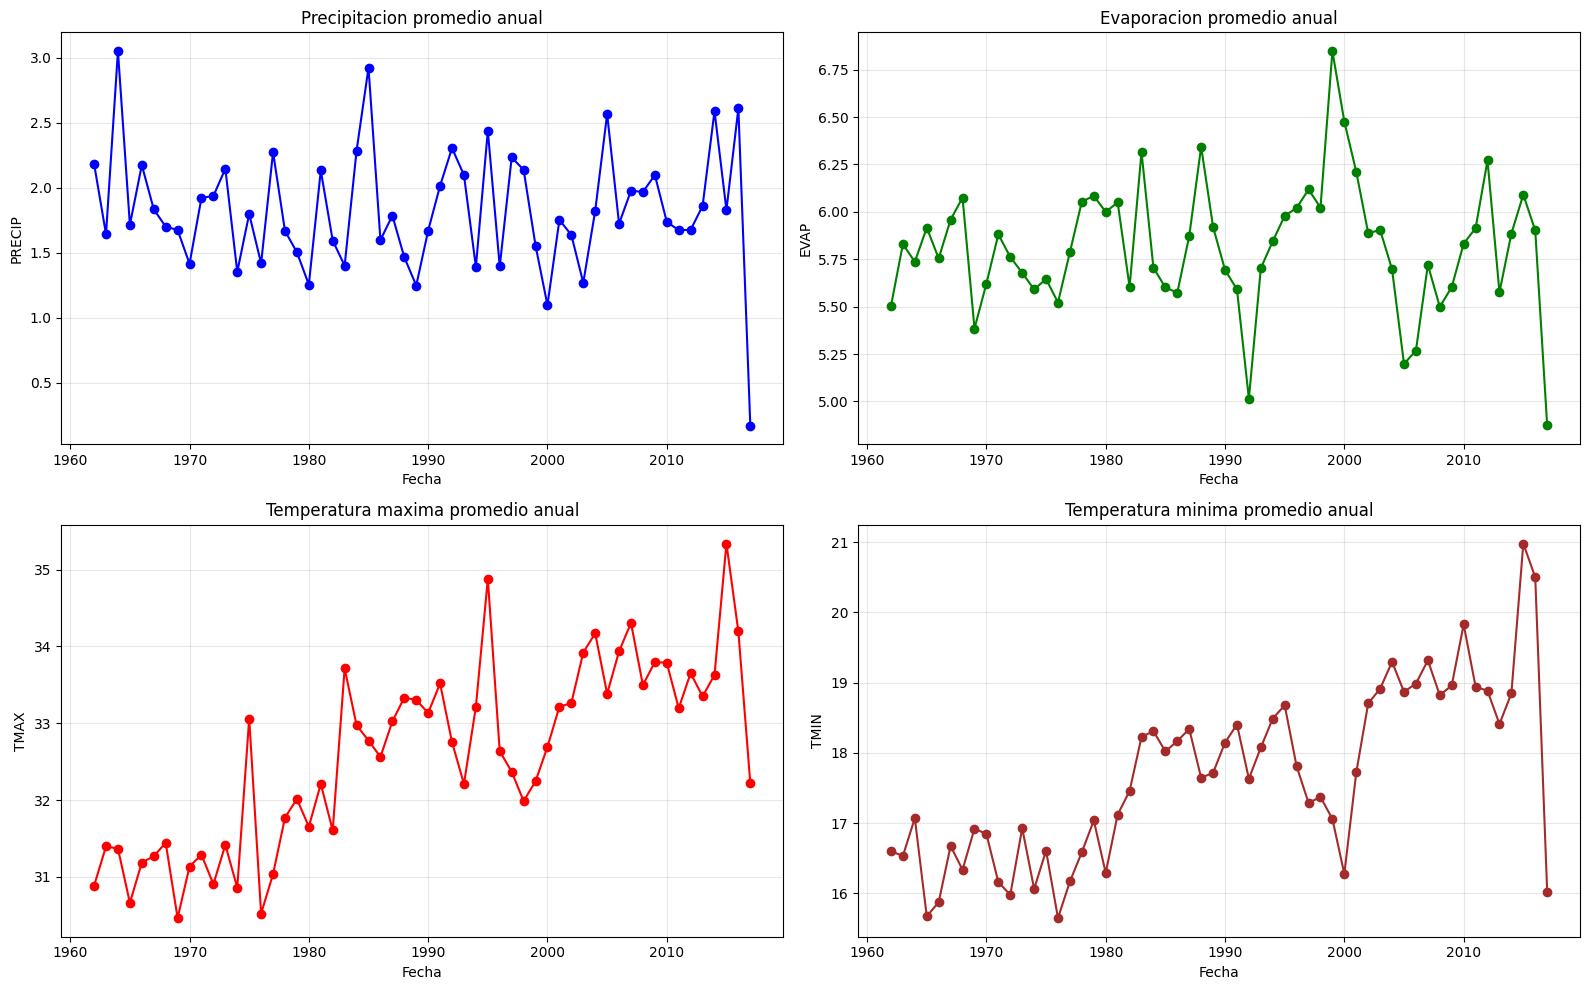

In [ ]:
import matplotlib.pyplot as plt
def grafica_linea_tendencias(df_temp):
    df_tendencias = df_temp.copy()
    df_tendencias['FECHA'] = pd.to_datetime(df_tendencias['FECHA'], dayfirst=True, errors='coerce')
    df_tendencias = df_tendencias.dropna(subset=['FECHA']).sort_values('FECHA')

    cols = ['PRECIP', 'EVAP', 'TMAX', 'TMIN']
    promedio_anual = df_tendencias.set_index('FECHA')[cols].resample('YE').mean()

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    titulos = ['Precipitacion promedio anual', 'Evaporacion promedio anual', 'Temperatura maxima promedio anual', 'Temperatura minima promedio anual']
    colores = ['blue', 'green', 'red', 'brown']

    for i, col in enumerate(cols):
        axes[i].plot(promedio_anual.index, promedio_anual[col], color=colores[i], marker='o', linewidth=1.5)
        axes[i].set_title(titulos[i])
        axes[i].set_xlabel('Fecha')
        axes[i].set_ylabel(col)
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

grafica_linea_tendencias(df)



**Precipitación:** La tendencia general se observa variable y con ligera disminución al final del periodo. Al inicio del registro el promedio anual ronda 2.18 mm, mientras que al final baja aproximadamente a 0.17 mm. Sin embargo, la precipitación no sigue una línea estable, porque depende de eventos de lluvia concentrados en ciertos días. Esto explica que la gráfica tenga picos aislados y cambios bruscos entre años.

**Evaporación:** Presenta un comportamiento relativamente estacionario, con una ligera tendencia decreciente. Sus promedios anuales se mantienen en un rango cercano, aproximadamente entre 4.88 mm y 6.59 mm. Esto sugiere que la evaporación es más constante que la lluvia, aunque puede variar por cambios de temperatura, humedad, viento o disponibilidad de agua en el ambiente.

**Temperatura máxima:** Muestra una tendencia ligeramente creciente. El promedio anual pasa aproximadamente de 30.89 °C al inicio a 32.22 °C al final del periodo. Esto puede relacionarse con variaciones climáticas de largo plazo, temporadas más cálidas o cambios locales en las condiciones de medición y urbanización.

**Temperatura mínima:** Tiene un comportamiento mayormente estacionario, aunque con variabilidad entre años. Sus promedios anuales se mueven entre valores aproximados de 15.65 °C y 20.98 °C. La variación puede explicarse por cambios estacionales, años más fríos o cálidos, y diferencias en las condiciones nocturnas.

En general, las variables de temperatura son más estables que la precipitación. La precipitación concentra la mayor variabilidad porque depende de eventos específicos de lluvia, mientras que evaporación, temperatura máxima y temperatura mínima muestran patrones más continuos a lo largo del tiempo.



## Comentarios y conclusiones

El análisis estadístico muestra que las variables climáticas no se comportan de la misma manera. La **precipitación** es la variable más irregular: su mediana y sus cuartiles son 0.00 mm, lo que indica que la mayoría de los días no llueve, pero cuando sí ocurre lluvia pueden aparecer valores muy altos. Por eso presenta una desviación estándar elevada, muchos valores atípicos y un sesgo positivo muy marcado.

La **evaporación** tiene un comportamiento más estable. Sus medidas de tendencia central se mantienen cercanas entre sí y su IQR es moderado, lo que indica que la mayoría de los registros se concentran alrededor de valores medios. Aunque existen algunos valores atípicos altos, estos no dominan tanto la distribución como sucede con la precipitación.

En las temperaturas, la **temperatura máxima** presenta una concentración fuerte alrededor de valores cálidos, con algunos valores atípicos tanto bajos como altos. La **temperatura mínima** muestra una mayor dispersión intercuartílica, lo que refleja diferencias importantes entre temporadas frías y cálidas, aunque no se detectaron valores atípicos con la regla del IQR.

Las gráficas ayudan a confirmar lo que muestran las medidas numéricas. Los histogramas y diagramas de densidad permiten observar la forma de las distribuciones: la precipitación aparece muy sesgada, mientras que evaporación y temperaturas tienen patrones más continuos. Los boxplots complementan esta lectura al mostrar cuartiles, dispersión y valores atípicos. Finalmente, las gráficas de línea permiten observar el comportamiento temporal: la precipitación varía mucho entre años, la evaporación se mantiene relativamente estable y la temperatura máxima muestra una ligera tendencia creciente.

En conjunto, los datos revelan que el clima de la estación analizada se caracteriza por **lluvias poco frecuentes pero ocasionalmente intensas**, **evaporación relativamente constante** y **temperaturas con variación estacional clara**. Esto es importante porque no basta con observar promedios: en variables como la precipitación, la media puede ser engañosa si no se revisan también la mediana, los cuartiles y los valores atípicos.

Desde una perspectiva práctica, este análisis puede servir para estudiar patrones climáticos, apoyar decisiones relacionadas con agricultura, manejo de agua o planeación ambiental, y comprender mejor la variabilidad histórica de la zona. Académicamente, permite aplicar conceptos de estadística descriptiva, limpieza de datos, análisis gráfico, detección de atípicos y análisis temporal dentro de un caso real.

Como limitaciones, el conjunto de datos contiene valores faltantes que fueron rellenados con la media, lo cual puede suavizar la variabilidad real de algunas variables. Además, el análisis se basa en una sola estación meteorológica, por lo que no necesariamente representa todo el comportamiento climático de la región. También sería conveniente revisar la calidad de los registros originales, validar posibles errores de captura y comparar los resultados con otras estaciones cercanas.

Como mejora, se recomienda ampliar el análisis usando más estaciones, separar los datos por temporada o mes, calcular tendencias con métodos estadísticos más formales y evaluar eventos extremos de manera independiente. Esto permitiría obtener conclusiones más sólidas sobre cambios climáticos, patrones estacionales y comportamiento de largo plazo.

